**NVDA stock price prediction**
### 1.1 Updated to use both Open and Close prices as features

In [ ]:
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, GRU
from sklearn.metrics import mean_squared_error
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
# Import the library
from sklearn.model_selection import train_test_split
import copy
import os

In [ ]:
# Load data from csv file
data_appl = pd.read_csv('NVDA.csv')

In [ ]:
# Data quality check
print(' NVDA Data Quality')
print(f'Missing values: {data_appl.isnull().sum().sum()}')
print(f'Duplicate rows: {data_appl.duplicated().sum()}')
print(f'Zero volume days: {(data_appl["Volume"] == 0).sum()}')
print(f'Zero price days: {(data_appl["Close"] == 0).sum()}')
print(f'\nDate range: {data_appl["Date"].iloc[0]} to {data_appl["Date"].iloc[-1]}')


 NVDA Data Quality
Missing values: 0
Duplicate rows: 0
Zero volume days: 0
Zero price days: 0

Date range: 22-01-1999 to 12-12-2022


In [ ]:
# Show some first data samples
data_appl.head()

,Date,Low,Open,Volume,High,Close,Adjusted Close
0,22-01-1999,0.388021,0.437500,271468800,0.488281,0.410156,0.376886
1,25-01-1999,0.410156,0.442708,51048000,0.458333,0.453125,0.416370
2,26-01-1999,0.411458,0.458333,34320000,0.467448,0.417969,0.384065
3,27-01-1999,0.395833,0.419271,24436800,0.429688,0.416667,0.382869
4,28-01-1999,0.412760,0.416667,22752000,0.419271,0.415365,0.381673


In [ ]:
# Get some info about the data
data_appl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6013 entries, 0 to 6012
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            6013 non-null   object 
 1   Low             6013 non-null   float64
 2   Open            6013 non-null   float64
 3   Volume          6013 non-null   int64  
 4   High            6013 non-null   float64
 5   Close           6013 non-null   float64
 6   Adjusted Close  6013 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 329.0+ KB


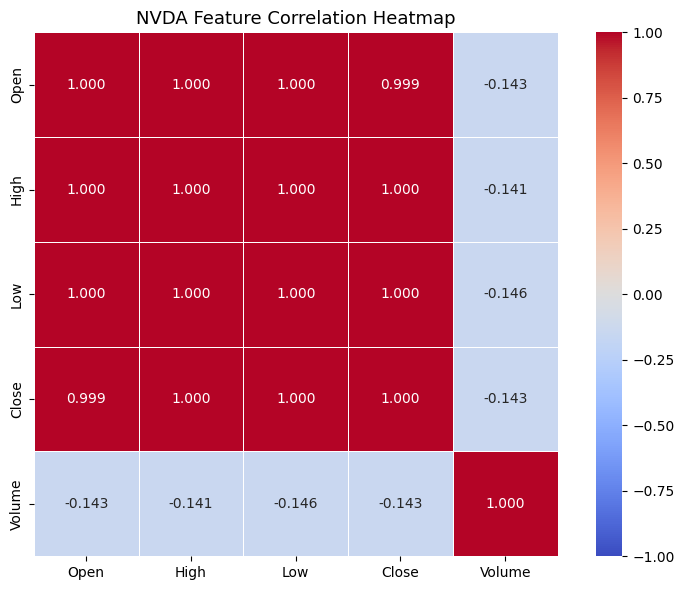

In [ ]:
#Correlation heatmap
df_eda = data_appl.copy()
plt.figure(figsize=(8, 6))
corr = df_eda[['Open', 'High', 'Low', 'Close', 'Volume']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('NVDA Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
df = data_appl
X_data = []
y_data = []
window_size = 30  ### Split the dataset into time windows to get data samples.

In [ ]:
open_col = df.columns.get_loc('Open')  #finding the position (index) of the 'Open' column inside dataset => return 2
close_col = df.columns.get_loc('Close')

In [ ]:
# Time window for data feature (size of 'number of days').

# Number of features: Open (col index 2) and Close (col index 4)

open_col = df.columns.get_loc('Open')  #finding the position (index) of the 'Open' column inside dataset => return 2
close_col = df.columns.get_loc('Close')
n_feature = 2  # Open + Close

for i in range(1, len(df) - window_size - 1):   #avoid going pass the dataset if we take one window at a time, each iteration creates one training example
    data_feature = []

    # Get a window_size time frame for data features (Open and Close)
    for j in range(window_size):
        open_price  = df.iloc[i + j, open_col]  #i as starting position of the window while j as offset inside the window (0 → 29)
        close_price = df.iloc[i + j, close_col] #We are extracting open/close price features for corresponding data
        data_feature.append([open_price, close_price])  #store as data feature

    # Label: next day's Open price
    data_label = [df.iloc[i + window_size, open_col]]

    # Append new data sample (feature and label) to X_data and y_data
    X_data.append(np.array(data_feature).reshape(window_size, n_feature))
    #Convert data_feature (30 pairs open_close price) into Numpy array then reshap to (30, 2)
    y_data.append(np.array(data_label))
    #Convert labels into numpy array, shape becomes (1,)

In [ ]:
### Split the data into training, validation and test set

# Split data into train, val and test. Note that 'shuffle=False' due to time-series data.
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val   = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)



In [ ]:
# Convert from lists to Numpy arrays for reshaping purpose
X_train = np.array(X_train)
X_val   = np.array(X_val)
X_test  = np.array(X_test)
y_train = np.array(y_train)
y_val   = np.array(y_val)
y_test  = np.array(y_test)

# Reshape to (samples, window_size, n_features=2)
X_train = X_train.reshape(X_train.shape[0], window_size, n_feature)
X_val   = X_val.reshape(X_val.shape[0],   window_size, n_feature)
X_test  = X_test.reshape(X_test.shape[0],  window_size, n_feature)



In [ ]:
# Print shape of the training, validation and test set
print("Shape of training set: ",   X_train.shape)
print("Shape of validation set: ", X_val.shape)
print("Shape of test set: ",       X_test.shape)

Shape of training set:  (3827, 30, 2)
Shape of validation set:  (957, 30, 2)
Shape of test set:  (1197, 30, 2)


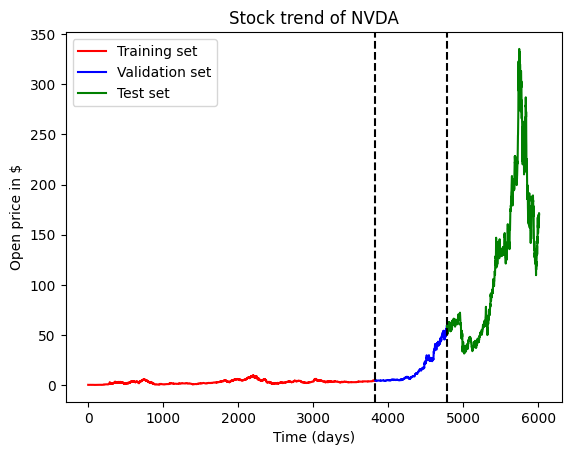

In [ ]:
# Visualize the training, validation and test set
df_plot = df['Open']
df_plot = df_plot.reset_index(drop=False)

# Get lengths of the three subsets
size_train = X_train.shape[0]
size_val   = X_val.shape[0]
size_test  = X_test.shape[0]

# Plot the subset splits
ax = df_plot.iloc[:size_train, 1:2].plot(y=0, color='red',   label='Training set')
df_plot.iloc[size_train:size_train+size_val, 1:2].plot(y=0, color='blue',  label='Validation set', ax=ax)
df_plot.iloc[size_train+size_val:df_plot.shape[0], 1:2].plot(y=0, color='green', label='Test set', ax=ax)
ax.set_title("Stock trend of NVDA")
plt.xlabel('Time (days)')
plt.ylabel('Open price in $')
plt.axvline(x=size_train,           color='black', linestyle='--')
plt.axvline(x=size_train+size_val,  color='black', linestyle='--')
plt.show()

In [ ]:
# MinMax normalize the training data per sample across all features.
# We compute min/max over the entire feature window (both Open and Close values)
# so that both columns are scaled to the same [0, 1] range within each sample.

def minmax_normalize(X, y):
    X_norm = X.copy().astype(float)  #Makes float copies of X and y so the originals aren't modified
    y_norm = y.copy().astype(float)
    mins, maxs = [], []
    for i in range(len(X)):
        min_val = np.min(X[i]) #For each sample, finds the min and max price across its entire  window - i as window number
        max_val = np.max(X[i])
        X_norm[i] = (X[i] - min_val) / (max_val - min_val) #normalize X with min/max within window
        y_norm[i] = (y[i] - min_val) / (max_val - min_val)
        mins.append(min_val) #Save each window's min and max so we can reverse the normalization later
        maxs.append(max_val)
    return X_norm, y_norm, np.array(mins), np.array(maxs)



In [ ]:
X_train_norm, y_train_norm, _, _           = minmax_normalize(X_train, y_train) #the mins/maxs for train and val aren't needed
X_val_norm,   y_val_norm,   _, _           = minmax_normalize(X_val,   y_val)
X_test_norm,  y_test_norm,  test_mins, test_maxs = minmax_normalize(X_test, y_test)

In [ ]:
print("Shape of training set X: ",   X_train_norm.shape)
print("Shape of training set y: ", y_train_norm.shape)

Shape of training set X:  (3827, 30, 2)
Shape of training set y:  (3827, 1)


In [ ]:
### Create and train the model

# Build the model architecture
# input_shape is (window_size, n_features) = (30, 2)
model = tf.keras.Sequential()
model.add(Conv1D(64,  kernel_size=3, activation='relu', input_shape=(window_size, n_feature), padding='same'))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))
model.add(Conv1D(64,  kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(1))  # Output: next day's Open price (linear activation)

# Compile and train the model with Mean Squared Error loss function (regression task)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
history = model.fit(X_train_norm, y_train_norm,
                    validation_data=(X_val_norm, y_val_norm),
                    epochs=30, batch_size=218)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - loss: 0.8579 - mse: 0.8579 - val_loss: 0.1708 - val_mse: 0.1708
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0853 - mse: 0.0853 - val_loss: 0.0586 - val_mse: 0.0586
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0269 - mse: 0.0269 - val_loss: 0.0197 - val_mse: 0.0197
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0115 - mse: 0.0115 - val_loss: 0.0166 - val_mse: 0.0166
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0089 - mse: 0.0089 - val_loss: 0.0152 - val_mse: 0.0152
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0082 - mse: 0.0082 - val_loss: 0.0178 - val_mse: 0.0178
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0080 - mse: 0.0080 - val_loss: 0.0147 - val_mse: 0.0147
Epoch 8/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0078 - mse: 0.0078 - val_loss: 0.0153 - val_mse: 0.0153
Epoch 9/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0076 - mse

In [ ]:
# Get prediction on the test data (normalized)
y_pred_norm = model.predict(X_test_norm)
print("MSE on the test set (normalized): ", mean_squared_error(y_pred_norm, y_test_norm))

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
MSE on the test set (normalized):  0.006852595626476312


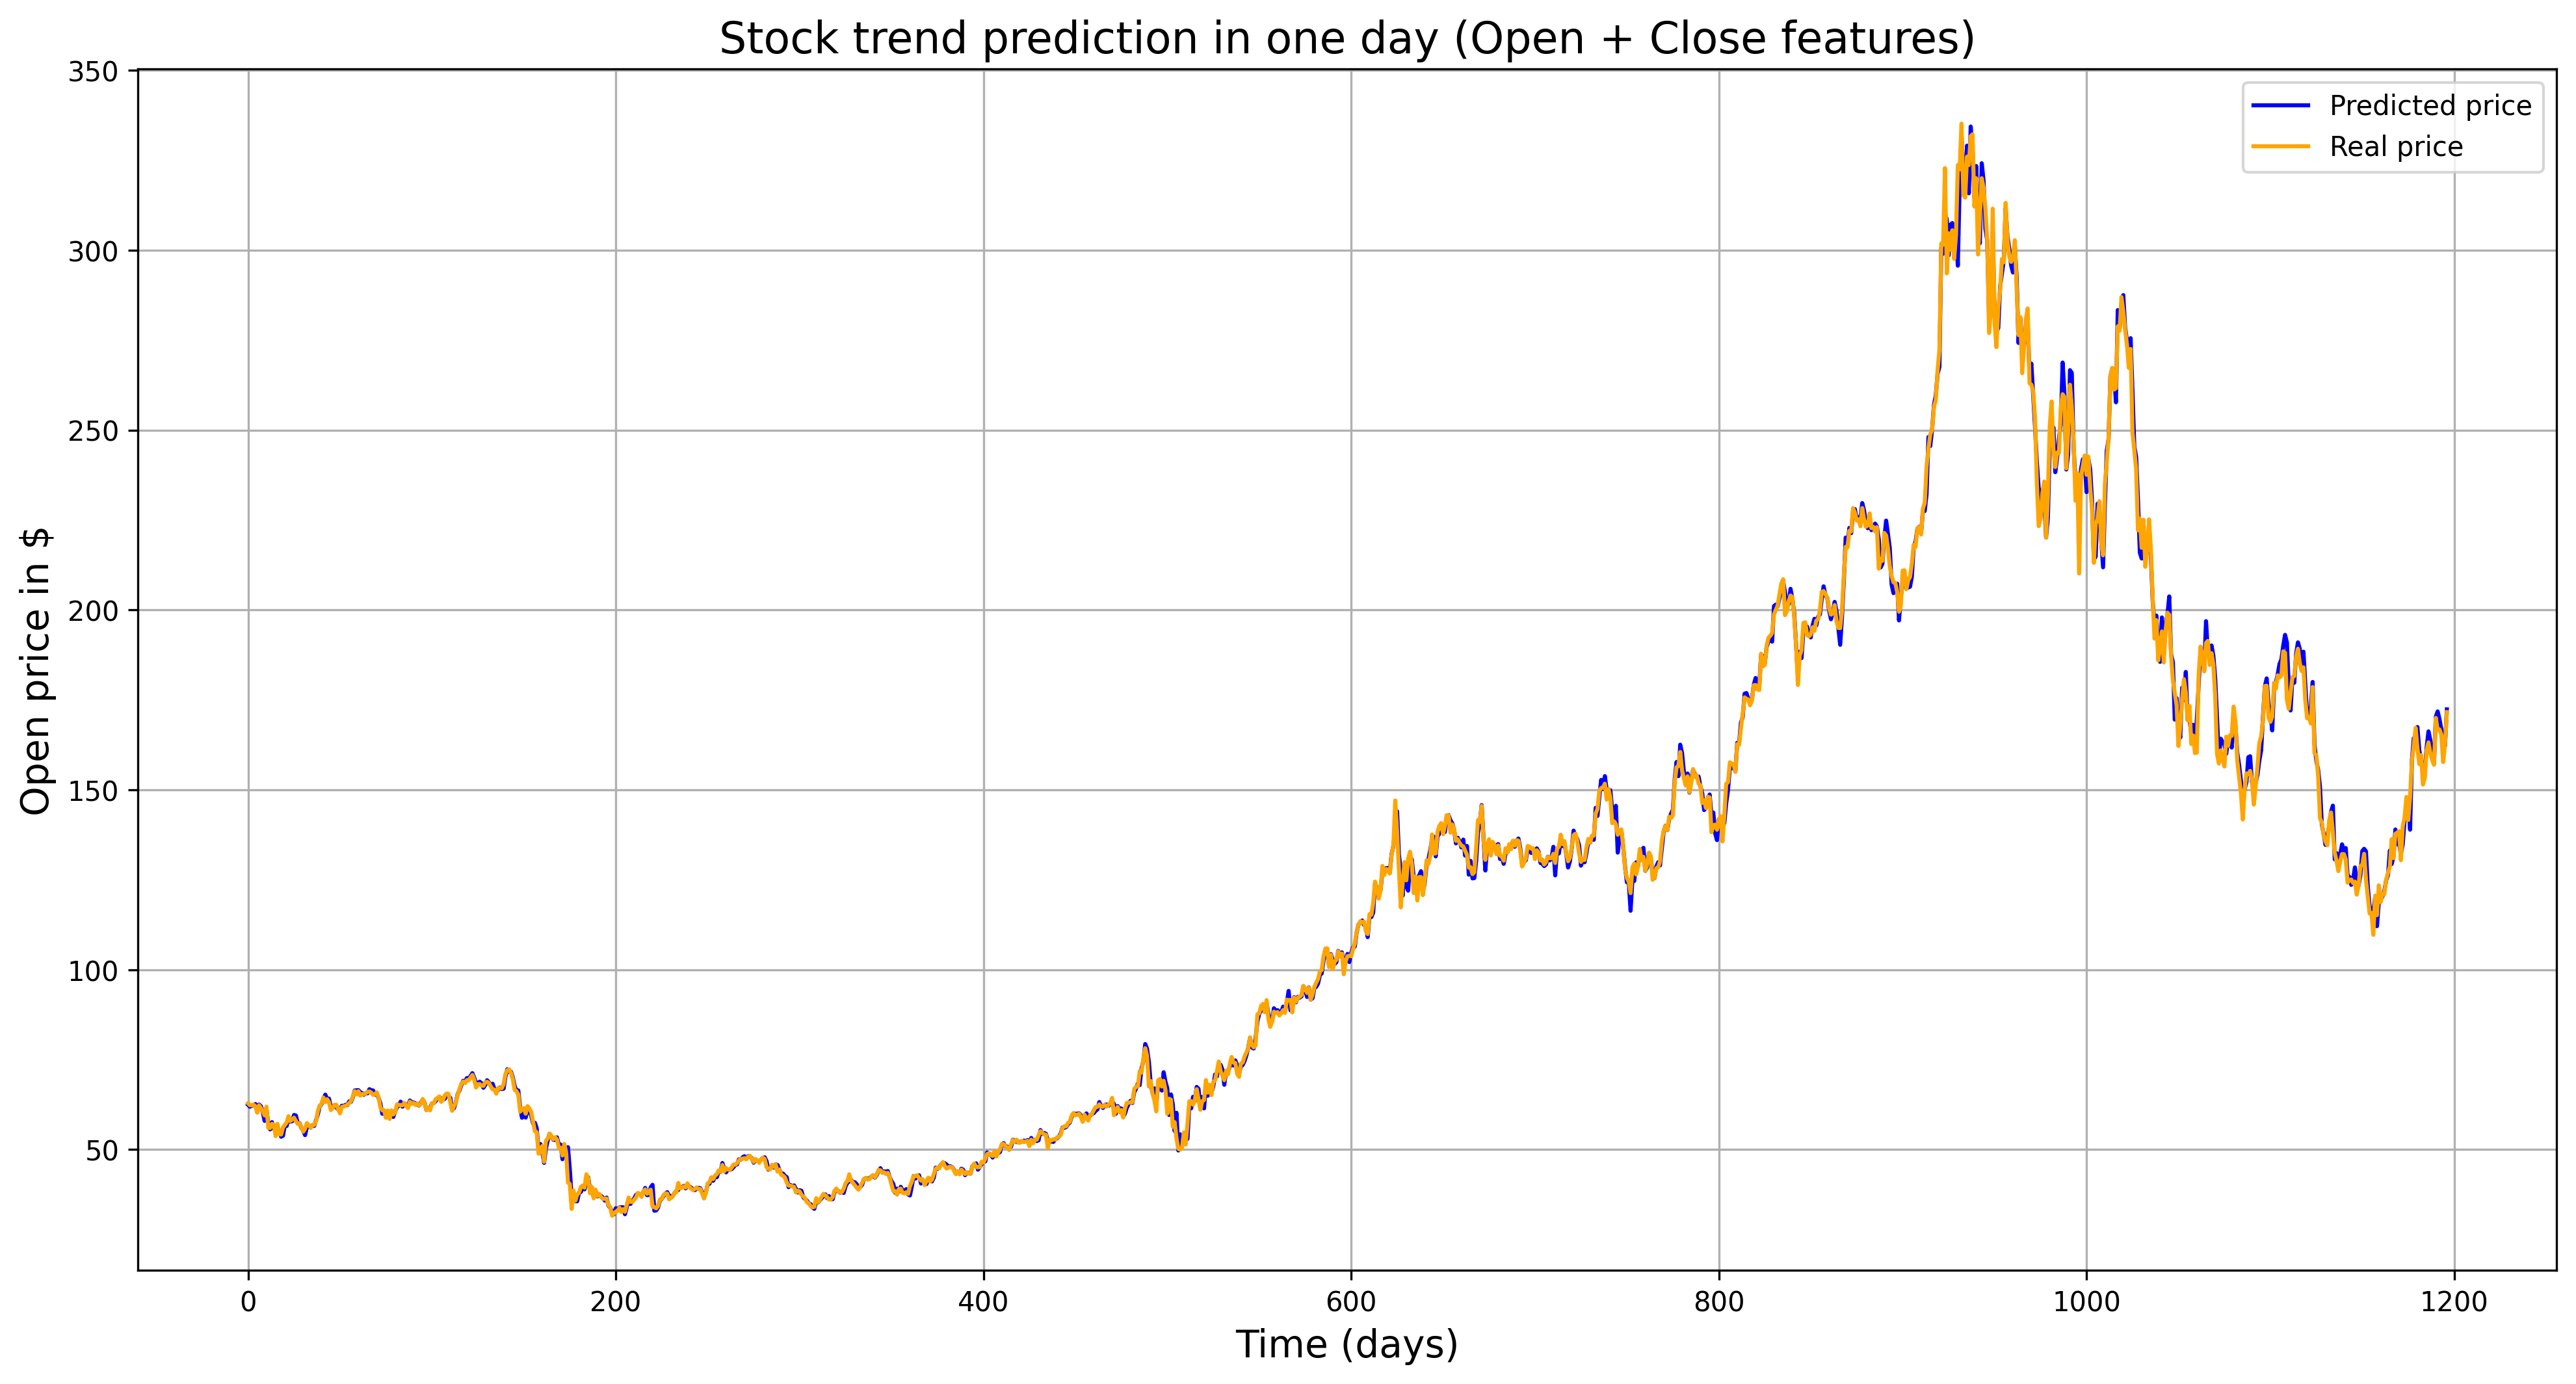

In [ ]:
# Convert the result back to stock price (de-normalization) for visualization
# denorm_x = norm_x * (max - min) + min
y_pred_denorm = y_pred_norm.copy()
for i in range(len(y_pred_denorm)):
    y_pred_denorm[i] = y_pred_norm[i] * (test_maxs[i] - test_mins[i]) + test_mins[i]

# Visualize predicted stock price versus real stock price
plt.figure(figsize=(16, 8), dpi=300)
plt.plot(y_pred_denorm, label='Predicted price', color='blue')
plt.plot(y_test,        label='Real price', color='orange')
plt.title('Stock trend prediction in one day (Open + Close features)', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Open price in $', fontsize=14)
plt.grid()
plt.legend()
plt.show()

**1.2 Predict k days ahead**

In [ ]:
X_datav2 = []
y_datav2 = []
  #finding the position (index) of the 'Low'/'High' column inside dataset
low_col = df.columns.get_loc('Low')
high_col = df.columns.get_loc('High')
n_features = 4  # Open + Close

In [ ]:
for i in range(1, len(df) - window_size - 3):   #training dataset now has different range
    data_featurev2 = []

    # Get a window_size time frame for data features (Open and Close)
    for j in range(window_size):  #i as starting position of the window while j as offset inside the window (0 → 29)
        low_price = df.iloc[i + j, low_col]
        high_price = df.iloc[i + j, high_col]
        open_price  = df.iloc[i + j, open_col]
        close_price = df.iloc[i + j, close_col]
        data_featurev2.append([open_price, close_price, low_price, high_price])  #store as data feature

    # Label: predict 4th day's Open price
    data_labelv2 = [df.iloc[i + 3 + window_size, open_col]]

    # Append new data sample (feature and label) to X_data and y_data
    X_datav2.append(np.array(data_featurev2).reshape(window_size, n_features))
    #Convert data_feature (30 pairs open_close price) into Numpy array then reshape
    y_datav2.append(np.array(data_labelv2))
    #Convert labels into numpy array, shape becomes (1,)

In [ ]:
X_trainv2, X_testv2, y_trainv2, y_testv2 = train_test_split(X_datav2, y_datav2, test_size=0.2, shuffle=False)
X_trainv2, X_valv2, y_trainv2, y_valv2   = train_test_split(X_trainv2, y_trainv2, test_size=0.2, shuffle=False)

X_trainv2 = np.array(X_trainv2)
X_valv2   = np.array(X_valv2)
X_testv2  = np.array(X_testv2)
y_trainv2 = np.array(y_trainv2)
y_valv2   = np.array(y_valv2)
y_testv2  = np.array(y_testv2)


In [ ]:
# MinMax normalize the new y data using the same mins/maxs from their corresponding X windows

X_train_norm_v2, y_train_norm_v2, _, _           = minmax_normalize(X_trainv2, y_trainv2)
X_val_norm_v2,   y_val_norm_v2,   _, _           = minmax_normalize(X_valv2,   y_valv2)
X_test_norm_v2,  y_test_norm_v2, test_minsv2, test_maxsv2 = minmax_normalize(X_testv2, y_testv2)


print("Shape of training set x: ",   X_train_norm_v2.shape)
print("Shape of traininf set y: ", y_train_norm_v2.shape)

Shape of training set x:  (3826, 30, 4)
Shape of traininf set y:  (3826, 1)


In [ ]:
def augment_volatile_windows(X_norm, y_norm, n_copies=5, scale_range=(2, 10)):
    X_aug, y_aug = [X_norm], [y_norm]
    for _ in range(n_copies):
        scale      = np.random.uniform(*scale_range) #Randomize scale range from 2-10
        mean       = X_norm.mean(axis=1, keepdims=True)
        X_volatile = mean + (X_norm - mean) * scale
        X_aug.append(X_volatile)
        # y is now (samples, 3)
        y_aug.append(1.0 + (y_norm - 1.0) * scale)
    return np.concatenate(X_aug), np.concatenate(y_aug)

def asymmetric_mse(alpha=2.0):
    def loss(y_true, y_pred):
        residual = y_true - y_pred
        # When residual > 0: model underpredicited → apply alpha penalty
        # When residual < 0: model overpredicted → normal penalty
        weight = tf.where(residual > 0, alpha, 1.0)
        return tf.reduce_mean(weight * tf.square(residual))
    return loss

In [ ]:
X_aug, y_aug = augment_volatile_windows(X_train_norm_v2, y_train_norm_v2)

In [ ]:
# Reshape to (samples, window_size, n_features=4)
X_aug = X_aug.reshape(X_aug.shape[0], window_size, n_features)
X_val_norm_v2   = X_val_norm_v2.reshape(X_val_norm_v2.shape[0],   window_size, n_features)
X_test_norm_v2  = X_test_norm_v2.reshape(X_test_norm_v2.shape[0],  window_size, n_features)
print("Shape of training set X: ",   X_aug.shape)
print("Shape of training set y: ", y_aug.shape)
## Final shape: (samples * 5, window, features)

Shape of training set X:  (22956, 30, 4)
Shape of training set y:  (22956, 1)


In [ ]:
# Function to build the model with a given learning rate
def build_model(learning_rate, window_size, n_features):
    modelv2 = Sequential()
    modelv2.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size, n_features), padding='same'))
    modelv2.add(MaxPooling1D(pool_size=2))
    modelv2.add(GRU(64, return_sequences=True))
    modelv2.add(GRU(32))
    modelv2.add(Dense(32, activation='relu'))
    modelv2.add(Dense(1))
    modelv2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss=asymmetric_mse(alpha=2.0),
                  metrics=['mse'])
    return modelv2

In [ ]:
# Define hyperparameters to tune
learning_rates = [0.001, 0.0005]
batch_sizes = [32, 64]
epochs_list = [25, 50] # Maximum epochs, EarlyStopping will stop earlier if no improvement

best_val_loss = float('inf')
best_hps = {}
best_model_found = None

# Setup callbacks for each training run
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=0.000001)


for lr in learning_rates:
    for bs in batch_sizes:
        for ep in epochs_list:
                print(f"\n--- Training with LR: {lr}, Batch Size: {bs}, Max Epochs: {ep}")
                current_model = build_model(lr, window_size, n_features)
                history = current_model.fit(
                    X_aug, y_aug,
                    validation_data=(X_val_norm_v2, y_val_norm_v2),
                    epochs=ep,
                    batch_size=bs,
                    callbacks=[early_stopping, reduce_lr],
                    verbose=0 # suppress output for each epoch
                )

                # Get the best validation loss from this run
                val_loss = min(history.history['val_loss'])

                print(f"Validation Loss for this run: {val_loss}")

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_hps = {'learning_rate': lr, 'batch_size': bs, 'epochs': ep}
                    best_model_found = current_model # Store the model with best weights
                    print(f"New best found! Best Val Loss: {best_val_loss}, HPs: {best_hps}")

print("\n--- Tuning Complete ---")
print(f"Best Validation Loss: {best_val_loss}")
print(f"Best Hyperparameters: {best_hps}")

# Assign the best model found to modelv2 for further use
modelv2 = best_model_found
if modelv2 is not None:
    print("Best model found during tuning has been assigned to 'modelv2'.")
else:
    print("No best model was found. 'modelv2' remains unchanged.")


--- Training with LR: 0.001, Batch Size: 32, Max Epochs: 25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Loss for this run: 0.15432611107826233
New best found! Best Val Loss: 0.15432611107826233, HPs: {'learning_rate': 0.001, 'batch_size': 32, 'epochs': 25}

--- Training with LR: 0.001, Batch Size: 32, Max Epochs: 50
Validation Loss for this run: 0.1498410403728485
New best found! Best Val Loss: 0.1498410403728485, HPs: {'learning_rate': 0.001, 'batch_size': 32, 'epochs': 50}

--- Training with LR: 0.001, Batch Size: 64, Max Epochs: 25
Validation Loss for this run: 0.1420726776123047
New best found! Best Val Loss: 0.1420726776123047, HPs: {'learning_rate': 0.001, 'batch_size': 64, 'epochs': 25}

--- Training with LR: 0.001, Batch Size: 64, Max Epochs: 50
Validation Loss for this run: 0.13689391314983368
New best found! Best Val Loss: 0.13689391314983368, HPs: {'learning_rate': 0.001, 'batch_size': 64, 'epochs': 50}

--- Training with LR: 0.0005, Batch Size: 32, Max Epochs: 25
Validation Loss for this run: 0.14750917255878448

--- Training with LR: 0.0005, Batch Size: 32, Max Ep

In [ ]:
static_model_weights = modelv2.get_weights()  # snapshot of tuned model

def walk_forward_predict(model, X_test, y_test, X_aug, y_aug,
                          retrain_every=30, finetune_epochs=5,
                          finetune_batch_size=32):
    predictions = []
    n_test      = len(X_test)

    for i in range(0, n_test, retrain_every):
        # ── 1. Predict current chunk BEFORE retraining ────────────
        chunk_X = X_test[i : i + retrain_every]
        chunk_preds = model.predict(chunk_X, verbose=0)
        predictions.extend(chunk_preds.flatten())
        print(f"Chunk {i}–{min(i+retrain_every, n_test)}: predicted {len(chunk_preds)} samples")

        # ── 2. Fine-tune on everything seen so far ────────────────
        if i > 0:
            X_seen = X_test[:i]                 # past test inputs  (no leak)
            y_seen = y_test[:i]                 # past test labels  (no leak)

            # Combine augmented train + real test data seen so far
            X_finetune = np.concatenate([X_aug,   X_seen])
            y_finetune = np.concatenate([y_aug,   y_seen])

            model.fit(
                X_finetune, y_finetune,
                epochs=finetune_epochs,         # short fine-tune
                batch_size=finetune_batch_size,
                verbose=0
            )
            print(f"  → Fine-tuned on {len(X_finetune)} samples "
                  f"({len(X_aug)} aug + {len(X_seen)} seen test)")

    return np.array(predictions[:n_test])


In [ ]:
wf_predictions_norm = walk_forward_predict(
    model              = modelv2,
    X_test             = X_test_norm_v2,
    y_test             = y_test_norm_v2,
    X_aug              = X_aug,
    y_aug              = y_aug,
    retrain_every      = 30,   # tune: smaller = adapts faster, slower to run
    finetune_epochs    = 5,    # tune: more = learns more, risks forgetting
    finetune_batch_size= 32
)


Chunk 0–30: predicted 30 samples
Chunk 30–60: predicted 30 samples
  → Fine-tuned on 22986 samples (22956 aug + 30 seen test)
Chunk 60–90: predicted 30 samples
  → Fine-tuned on 23016 samples (22956 aug + 60 seen test)
Chunk 90–120: predicted 30 samples
  → Fine-tuned on 23046 samples (22956 aug + 90 seen test)
Chunk 120–150: predicted 30 samples
  → Fine-tuned on 23076 samples (22956 aug + 120 seen test)
Chunk 150–180: predicted 30 samples
  → Fine-tuned on 23106 samples (22956 aug + 150 seen test)
Chunk 180–210: predicted 30 samples
  → Fine-tuned on 23136 samples (22956 aug + 180 seen test)
Chunk 210–240: predicted 30 samples
  → Fine-tuned on 23166 samples (22956 aug + 210 seen test)
Chunk 240–270: predicted 30 samples
  → Fine-tuned on 23196 samples (22956 aug + 240 seen test)
Chunk 270–300: predicted 30 samples
  → Fine-tuned on 23226 samples (22956 aug + 270 seen test)
Chunk 300–330: predicted 30 samples
  → Fine-tuned on 23256 samples (22956 aug + 300 seen test)
Chunk 330–360: 

In [ ]:
print("MSE on the test set (normalized): ", mean_squared_error(wf_predictions_norm, y_test_norm_v2))

MSE on the test set (normalized):  0.07737388050450128


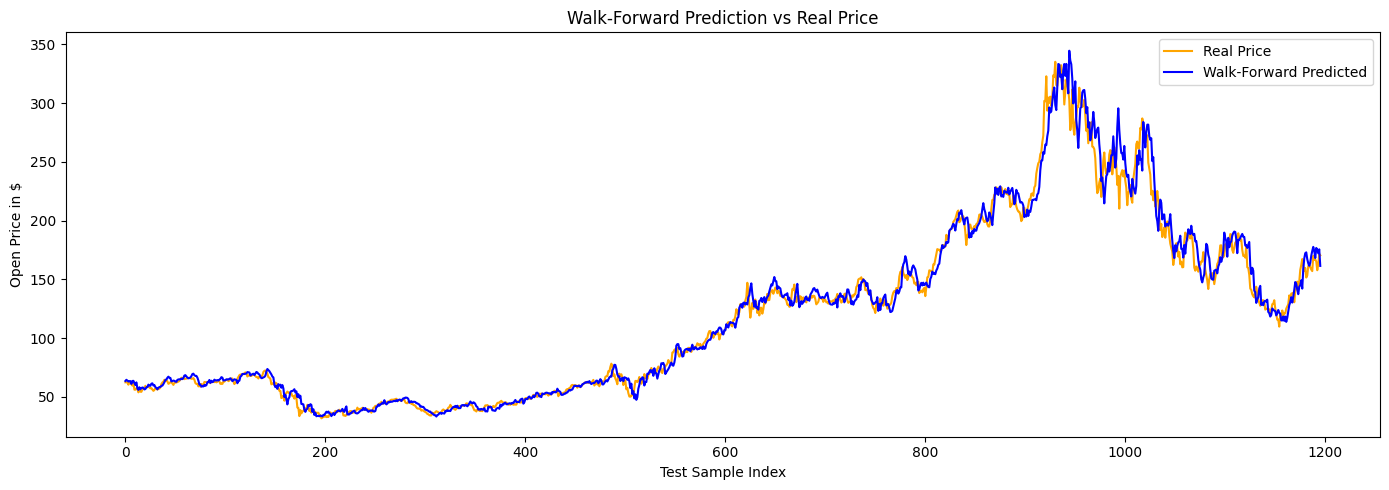

In [ ]:
wf_predictions_raw = (wf_predictions_norm * (test_maxsv2 - test_minsv2)) + test_minsv2
plt.figure(figsize=(14, 5))
plt.plot(y_testv2,          label='Real Price',            color='orange')
plt.plot(wf_predictions_raw,  label='Walk-Forward Predicted', color='blue')
plt.title('Walk-Forward Prediction vs Real Price')
plt.xlabel('Test Sample Index')
plt.ylabel('Open Price in $')
plt.legend()
plt.tight_layout()
plt.show()

**1.3 Predict 3 days ahead**

In [ ]:
n_ahead     = 3
X_datav3, y_datav3 = [], []

for i in range(1, len(df) - window_size - n_ahead):
    data_featurev3 = []
    for j in range(window_size):
        open_price  = df.iloc[i + j, open_col]
        close_price = df.iloc[i + j, close_col]
        low_price   = df.iloc[i + j, low_col]
        high_price  = df.iloc[i + j, high_col]
        data_featurev3.append([open_price, close_price, low_price, high_price])

    #Collect all 3 future labels

    data_labelv3 = [
        df.iloc[i + window_size + 1, open_col],   # day+2
        df.iloc[i + window_size + 2, open_col],   # day+3
        df.iloc[i + window_size + 3, open_col],   # day+4
    ]

    X_datav3.append(np.array(data_featurev3).reshape(window_size, n_features))
    y_datav3.append(np.array(data_labelv3))        # shape: (3,)

In [ ]:
X_trainv3, X_testv3, y_trainv3, y_testv3 = train_test_split(X_datav3, y_datav3, test_size=0.2, shuffle=False)
X_trainv3, X_valv3, y_trainv3, y_valv3   = train_test_split(X_trainv3, y_trainv3, test_size=0.2, shuffle=False)
X_trainv3 = np.array(X_trainv3)
X_valv3  = np.array(X_valv3)
X_testv3  = np.array(X_testv3)
y_trainv3 = np.array(y_trainv3)   # shape: (samples, 3)
y_valv3   = np.array(y_valv3)
y_testv3  = np.array(y_testv3)

In [ ]:
X_train_norm_v3, y_train_norm_v3, _, _                      = minmax_normalize(X_trainv3, y_trainv3)
X_val_norm_v3,   y_val_norm_v3,   _, _                      = minmax_normalize(X_valv3,   y_valv3)
X_test_norm_v3,  y_test_norm_v3,  test_minsv3, test_maxsv3  = minmax_normalize(X_testv3,  y_testv3)

X_train_norm_v3 = X_train_norm_v3.reshape(X_train_norm_v3.shape[0], window_size, n_features)
X_val_norm_v3   = X_val_norm_v3.reshape(X_val_norm_v3.shape[0],     window_size, n_features)
X_test_norm_v3  = X_test_norm_v3.reshape(X_test_norm_v3.shape[0],   window_size, n_features)

In [ ]:
def build_model_v3(learning_rate, window_size, n_features, n_ahead):

    modelv3 = Sequential([
        Conv1D(64, kernel_size=3, activation='relu',
               input_shape=(window_size, n_features), padding='same'),
        MaxPooling1D(pool_size=2),
        GRU(64, return_sequences=True),
        GRU(32),
        Dense(32, activation='relu'),
        Dense(n_ahead)                 # from Dense(1) to Dense(3)
    ])
    modelv3.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=asymmetric_mse(alpha=2.0),
        metrics=['mse']
    )
    return modelv3

def walk_forward_predict(model, X_test, y_test, X_aug, y_aug,
                          retrain_every=30, finetune_epochs=5,
                          finetune_batch_size=32):
    predictions = []
    n_test      = len(X_test)

    for i in range(0, n_test, retrain_every):
        chunk_X     = X_test[i : i + retrain_every]
        chunk_preds = model.predict(chunk_X, verbose=0)  # shape: (chunk, 3)
        predictions.extend(chunk_preds)                  # store (chunk, 3) rows
        print(f"Chunk {i}–{min(i + retrain_every, n_test)}: "
              f"predicted {len(chunk_preds)} samples")
        if i > 0:
            X_seen     = X_test[:i]
            y_seen     = y_test[:i]
            X_finetune = np.concatenate([X_aug,  X_seen])
            y_finetune = np.concatenate([y_aug,  y_seen])
            model.fit(
                X_finetune, y_finetune,
                epochs=finetune_epochs,
                batch_size=finetune_batch_size,
                verbose=0
            )
            print(f"  → Fine-tuned on {len(X_aug)} aug + "
                  f"{len(X_seen)} seen test samples")

    predictions = np.array(predictions[:n_test])  # shape: (n_test, 3)
    return predictions

In [ ]:
# Augment training data with lower scale
X_aug_v3, y_aug_v3 = augment_volatile_windows(
    X_train_norm_v3, y_train_norm_v3,
    n_copies=5, scale_range=(2, 10)
)
X_aug_v3 = X_aug_v3.reshape(X_aug_v3.shape[0], window_size, n_features)

# Train
learning_rate = 0.001
batch_size    = 32
epochs        = 30

modelv3 = build_model_v3(learning_rate, window_size, n_features, n_ahead)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = modelv3.fit(
    X_aug_v3, y_aug_v3,
    validation_data=(X_val_norm_v3, y_val_norm_v3),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=15,
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=7, min_lr=1e-6)
    ],
    verbose=1
)


Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 2.2511 - mse: 1.7279 - val_loss: 0.1103 - val_mse: 0.0692 - learning_rate: 0.0010
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1.8580 - mse: 1.3839 - val_loss: 0.1270 - val_mse: 0.0758 - learning_rate: 0.0010
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1.7903 - mse: 1.3330 - val_loss: 0.1093 - val_mse: 0.0662 - learning_rate: 0.0010
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 1.7151 - mse: 1.2747 - val_loss: 0.1030 - val_mse: 0.0767 - learning_rate: 0.0010
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1.6202 - mse: 1.2071 - val_loss: 0.1163 - val_mse: 0.0668 - learning_rate: 0.0010
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 1.5546 - mse: 1.1625 - val_loss: 0.1237 - val_mse: 0.0719 - learning_rate: 0.0010
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 1.4394 - mse: 1.0819 - val_loss: 0.1009 - val_mse: 0.0663 - learning_rate: 0.0010
Epoc

In [ ]:
#Walk-forward prediction
wf_predictions_normv3 = walk_forward_predict(
    model               = modelv3,
    X_test              = X_test_norm_v3,
    y_test              = y_test_norm_v3,
    X_aug               = X_aug_v3,
    y_aug               = y_aug_v3,
    retrain_every       = 30,
    finetune_epochs     = 5,
    finetune_batch_size = 32
)
# shape: (n_test, 3)

Chunk 0–30: predicted 30 samples
Chunk 30–60: predicted 30 samples
  → Fine-tuned on 22956 aug + 30 seen test samples
Chunk 60–90: predicted 30 samples
  → Fine-tuned on 22956 aug + 60 seen test samples
Chunk 90–120: predicted 30 samples
  → Fine-tuned on 22956 aug + 90 seen test samples
Chunk 120–150: predicted 30 samples
  → Fine-tuned on 22956 aug + 120 seen test samples
Chunk 150–180: predicted 30 samples
  → Fine-tuned on 22956 aug + 150 seen test samples
Chunk 180–210: predicted 30 samples
  → Fine-tuned on 22956 aug + 180 seen test samples
Chunk 210–240: predicted 30 samples
  → Fine-tuned on 22956 aug + 210 seen test samples
Chunk 240–270: predicted 30 samples
  → Fine-tuned on 22956 aug + 240 seen test samples
Chunk 270–300: predicted 30 samples
  → Fine-tuned on 22956 aug + 270 seen test samples
Chunk 300–330: predicted 30 samples
  → Fine-tuned on 22956 aug + 300 seen test samples
Chunk 330–360: predicted 30 samples
  → Fine-tuned on 22956 aug + 330 seen test samples
Chunk 3

In [ ]:
# Reshape to (samples, 1) so it broadcasts across 3 day predictions
test_minsv3_r = test_minsv3.reshape(-1, 1)  # (1196, 1)
test_maxsv3_r = test_maxsv3.reshape(-1, 1)  # (1196, 1)

# Now shapes are compatible:
# predictions:  (1196, 3)
# mins/maxs:    (1196, 1) → broadcasts to (1196, 3)
wf_predictions_rawv3 = (wf_predictions_normv3 * (test_maxsv3_r - test_minsv3_r)) + test_minsv3_r
y_test_rawv3         = (y_test_norm_v3        * (test_maxsv3_r - test_minsv3_r)) + test_minsv3_r

Day+1 → MSE:59.5380
Day+2 → MSE:85.6632
Day+3 → MSE:122.0340


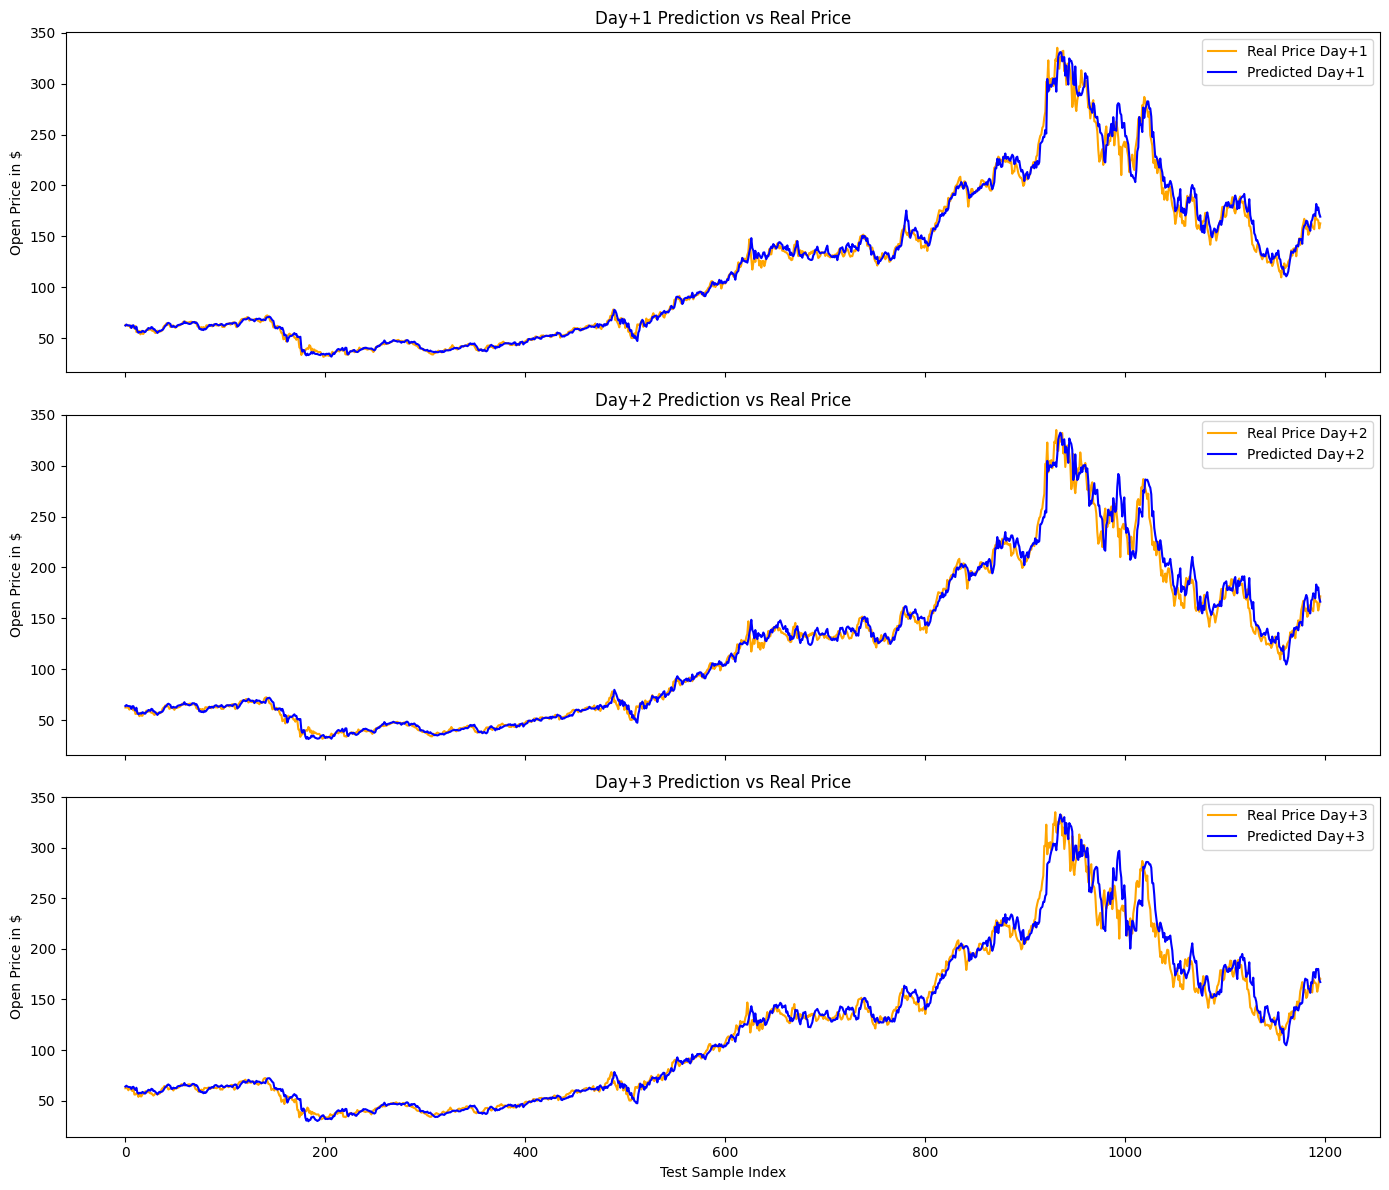

In [ ]:
for day in range(n_ahead):
    mse  = np.mean((wf_predictions_rawv3[:, day] - y_test_rawv3[:, day]) ** 2)
    print(f"Day+{day+1} → MSE:{mse:.4f}")

#Plot all 3 horizons
fig, axes = plt.subplots(n_ahead, 1, figsize=(14, 4 * n_ahead), sharex=True)

for day in range(n_ahead):
    axes[day].plot(y_test_rawv3[:, day],
                   label=f'Real Price Day+{day+1}',  color='orange')
    axes[day].plot(wf_predictions_rawv3[:, day],
                   label=f'Predicted Day+{day+1}',   color='blue')
    axes[day].set_title(f'Day+{day+1} Prediction vs Real Price')
    axes[day].set_ylabel('Open Price in $')
    axes[day].legend()

axes[-1].set_xlabel('Test Sample Index')
plt.tight_layout()
plt.show()

In [ ]:
# Save modelv3 — 3-day ahead prediction model

MODEL_SAVE_PATH = 'modelv3_stock_prediction.keras'   # change path as needed

modelv3.save(MODEL_SAVE_PATH)
print(f'modelv3 saved to: {os.path.abspath(MODEL_SAVE_PATH)}')

# Verify the file was written
size_mb = os.path.getsize(MODEL_SAVE_PATH) / 1024 / 1024
print(f'   File size: {size_mb:.2f} MB')

modelv3 saved to: /content/modelv3_stock_prediction.keras
   File size: 0.46 MB


**Evaluate on the other dataset of Nasdaq**

 Loaded Micron: 9713 rows  |  1984-06-01  →  2022-12-12


,Date,Low,Open,Volume,High,Close,Adjusted Close
0,1984-06-01,1.4125,0.0,7340000,1.4250,1.4125,1.385186
1,1984-06-04,1.4125,0.0,4067000,1.4250,1.4125,1.385186
2,1984-06-05,1.4000,0.0,2089000,1.4125,1.4000,1.372928
3,1984-06-06,1.4750,0.0,1894000,1.5000,1.4750,1.446478
4,1984-06-07,1.6375,0.0,2078000,1.6500,1.6375,1.605836


Micron Dataset — Basic Info
Shape : (9713, 7)
Missing values:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64



,Date,Open,High,Low,Close,Volume
count,9713,9713.000000,9713.000000,9713.000000,9713.000000,9.713000e+03
mean,2003-08-31 08:22:35.049933056,19.039334,19.625100,18.792289,19.201430,1.579018e+07
min,1984-06-01 00:00:00,0.000000,0.375000,0.337500,0.350000,8.100000e+04
25%,1994-01-07 00:00:00,4.190000,4.337500,4.010000,4.170000,5.473800e+06
50%,2003-08-28 00:00:00,12.375000,12.640000,12.125000,12.375000,1.157320e+07
75%,2013-04-23 00:00:00,27.930000,28.379999,27.375000,27.790001,2.245540e+07
max,2022-12-12 00:00:00,97.000000,98.449997,95.300003,97.360001,1.539061e+08
std,NaN,20.474573,20.702826,19.872365,20.284792,1.447082e+07


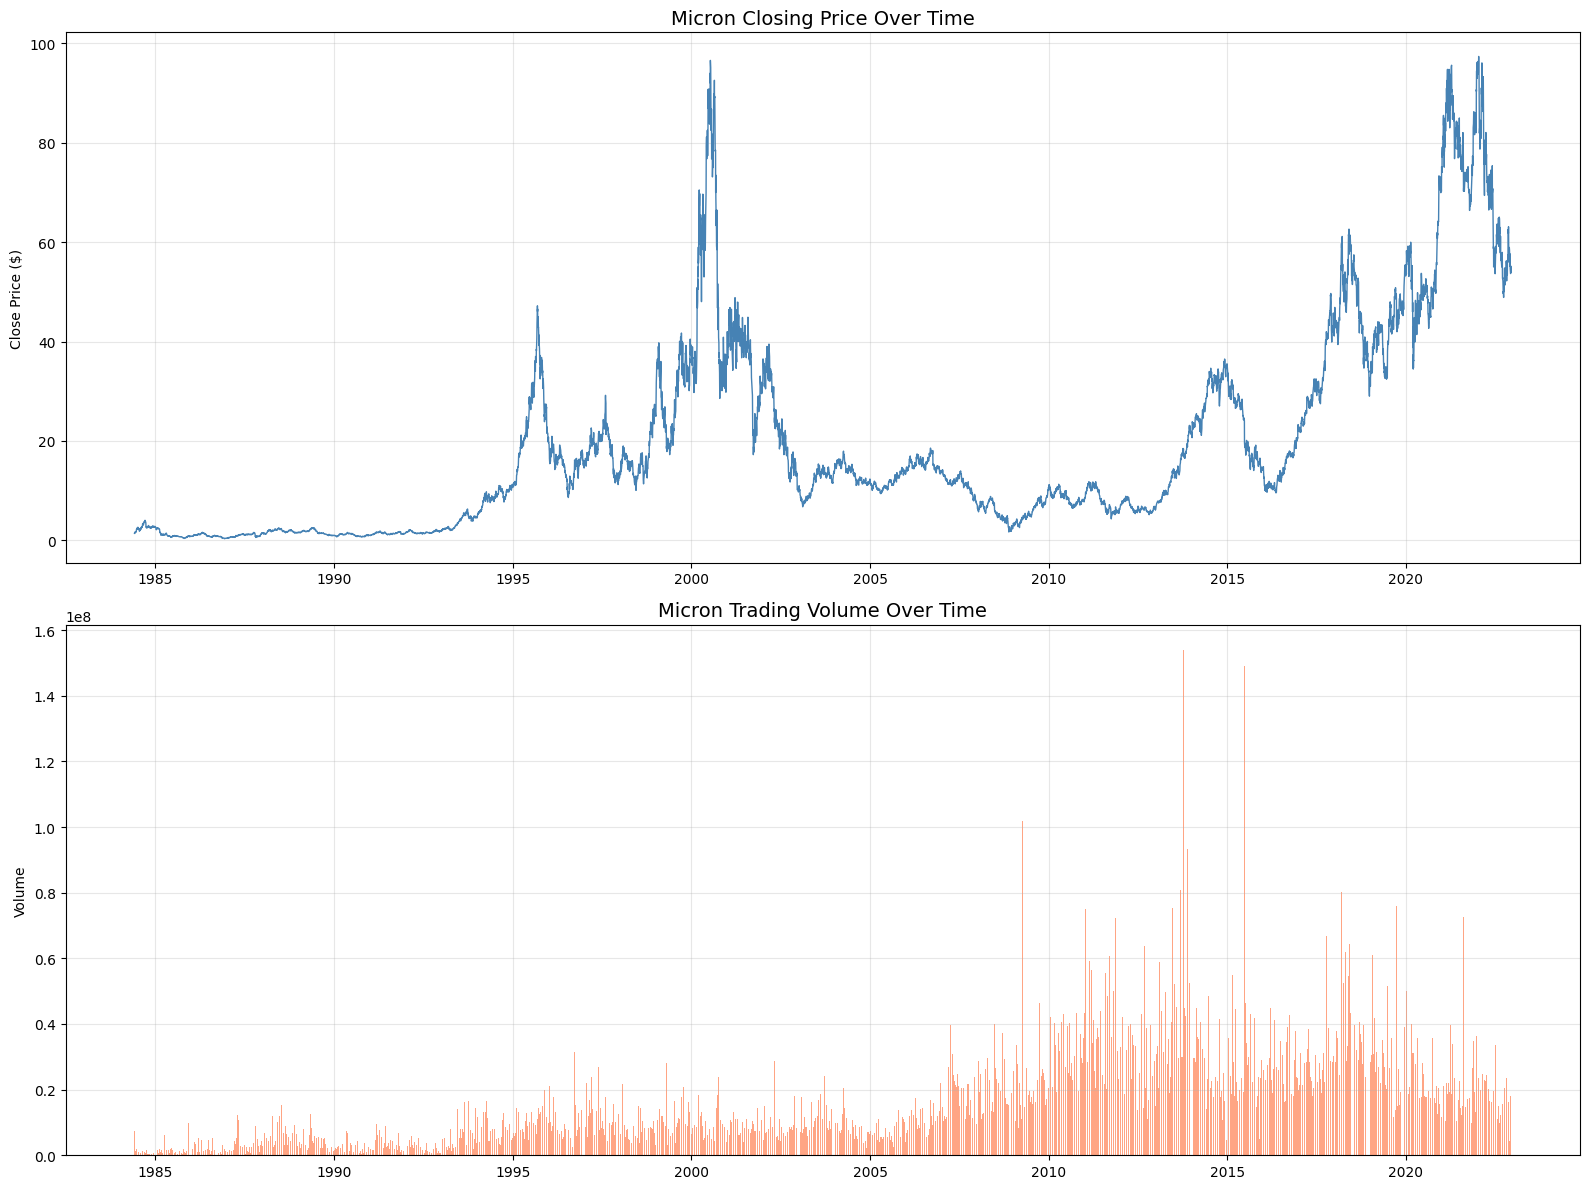

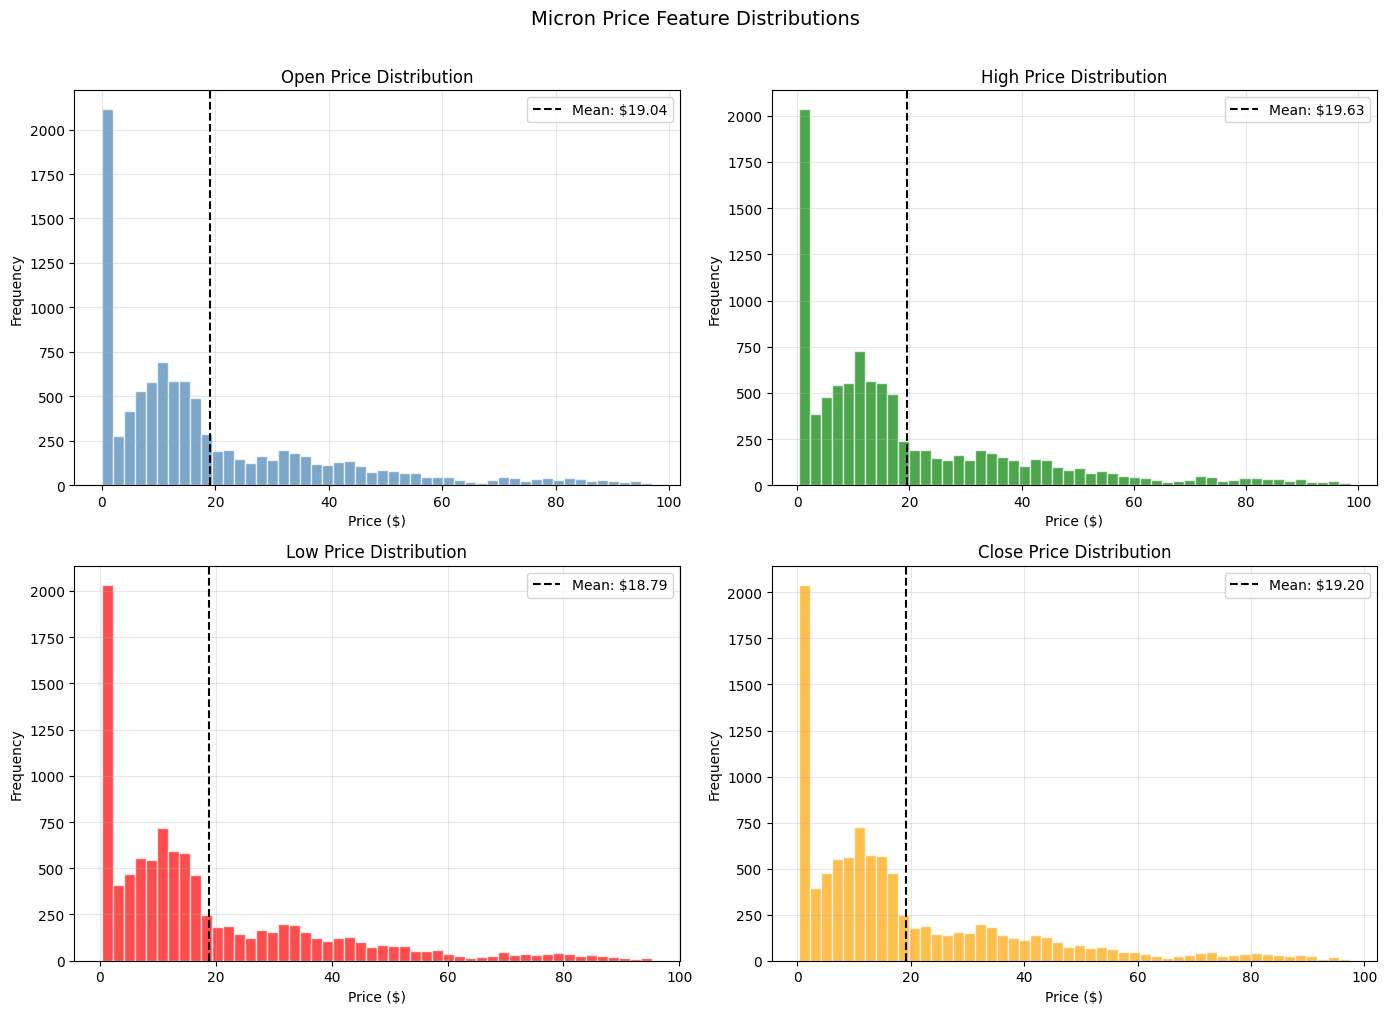

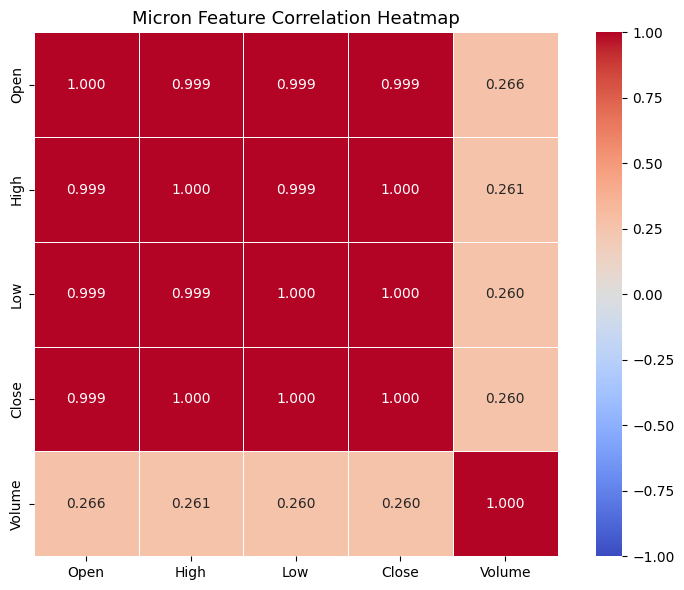

In [ ]:
NEW_CSV_PATH   = 'MU.csv'          # path to your new stock CSV file
TICKER_LABEL   = 'Micron'              # used in plot titles
MODEL_LOAD_PATH = 'modelv3_stock_prediction.keras'   # saved model path

# Load & validate the new dataset

required_cols = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

df_new = pd.read_csv(NEW_CSV_PATH)
missing = [c for c in required_cols if c not in df_new.columns]
assert not missing, f'Missing columns in new CSV: {missing}'

df_new['Date'] = pd.to_datetime(df_new['Date'], dayfirst=True) # Added dayfirst=True
df_new = df_new.sort_values('Date').reset_index(drop=True)

print(f' Loaded {TICKER_LABEL}: {df_new.shape[0]} rows  |  '
      f'{df_new["Date"].iloc[0].date()}  →  {df_new["Date"].iloc[-1].date()}')
display(df_new.head())


# EDA — New dataset
print('='*60)
print(f'{TICKER_LABEL} Dataset — Basic Info')
print('='*60)
print(f'Shape : {df_new.shape}')
print(f'Missing values:\n{df_new[required_cols].isnull().sum()}')
print()
display(df_new[required_cols].describe())

df_new['Daily_Return'] = df_new['Close'].pct_change() * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

axes[0].plot(df_new['Date'], df_new['Close'], color='steelblue', linewidth=1)
axes[0].set_title(f'{TICKER_LABEL} Closing Price Over Time', fontsize=14)
axes[0].set_ylabel('Close Price ($)')
axes[0].grid(alpha=0.3)

axes[1].bar(df_new['Date'], df_new['Volume'], color='coral', alpha=0.7, width=1)
axes[1].set_title(f'{TICKER_LABEL} Trading Volume Over Time', fontsize=14)
axes[1].set_ylabel('Volume')
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

# Distribution + correlation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
price_cols = ['Open', 'High', 'Low', 'Close']
colors = ['steelblue', 'green', 'red', 'orange']
for ax, col, color in zip(axes.flatten(), price_cols, colors):
    ax.hist(df_new[col], bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(f'{col} Price Distribution', fontsize=12)
    ax.set_xlabel('Price ($)')
    ax.set_ylabel('Frequency')
    ax.axvline(df_new[col].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: ${df_new[col].mean():.2f}')
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle(f'{TICKER_LABEL} Price Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
corr_new = df_new[['Open', 'High', 'Low', 'Close', 'Volume']].corr()
sns.heatmap(corr_new, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title(f'{TICKER_LABEL} Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
loaded_modelv3 = tf.keras.models.load_model(
    MODEL_LOAD_PATH,
    custom_objects={'loss': asymmetric_mse(alpha=2.0)}
)

In [ ]:
df_apply = df_new.copy()
open_col_n  = df_apply.columns.get_loc('Open')
close_col_n = df_apply.columns.get_loc('Close')
low_col_n   = df_apply.columns.get_loc('Low')
high_col_n  = df_apply.columns.get_loc('High')

X_new, y_new = [], []
for i in range(1, len(df_apply) - window_size - n_ahead):
    window = []
    for j in range(window_size):
        window.append([
            df_apply.iloc[i + j, open_col_n],
            df_apply.iloc[i + j, close_col_n],
            df_apply.iloc[i + j, low_col_n],
            df_apply.iloc[i + j, high_col_n],
        ])
    X_new.append(np.array(window))
    y_new.append(np.array([
        df_apply.iloc[i + window_size + 1, open_col_n],
        df_apply.iloc[i + window_size + 2, open_col_n],
        df_apply.iloc[i + window_size + 3, open_col_n],
    ]))

X_new_tr, X_new_te, y_new_tr, y_new_te = train_test_split(X_new, y_new, test_size=0.2, shuffle=False)
X_new_tr, X_new_va, y_new_tr, y_new_va = train_test_split(X_new_tr, y_new_tr, test_size=0.2, shuffle=False)

X_new_tr = np.array(X_new_tr)
X_new_va = np.array(X_new_va)
X_new_te = np.array(X_new_te)
y_new_tr = np.array(y_new_tr)
y_new_va = np.array(y_new_va)
y_new_te = np.array(y_new_te)


In [ ]:
# MinMax normalise (same function defined earlier)
X_new_tr_n, y_new_tr_n, _, _                         = minmax_normalize(X_new_tr, y_new_tr)
X_new_va_n, y_new_va_n, _, _                         = minmax_normalize(X_new_va, y_new_va)
X_new_te_n, y_new_te_n, new_test_mins, new_test_maxs = minmax_normalize(X_new_te, y_new_te)

X_new_tr_n = X_new_tr_n.reshape(-1, window_size, n_features)
X_new_va_n = X_new_va_n.reshape(-1, window_size, n_features)
X_new_te_n = X_new_te_n.reshape(-1, window_size, n_features)

print(f'Train: {X_new_tr_n.shape}  |  Val: {X_new_va_n.shape}  |  Test: {X_new_te_n.shape}')

Train: (6194, 30, 4)  |  Val: (1549, 30, 4)  |  Test: (1936, 30, 4)


In [ ]:
#Augment new training data
X_aug_new, y_aug_new = augment_volatile_windows(
    X_new_tr_n, y_new_tr_n, n_copies=5, scale_range=(2, 10)
)
X_aug_new = X_aug_new.reshape(-1, window_size, n_features)


In [ ]:
#Fine-tune the loaded model on the new ticker's training data
print(f'Fine-tuning loaded modelv3 on {TICKER_LABEL} training data')

loaded_modelv3.fit(
    X_aug_new, y_aug_new,
    validation_data=(X_new_va_n, y_new_va_n),
    epochs=20,
    batch_size=32,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ],
    verbose=1
)
print(f'Fine-tuning complete.')

Fine-tuning loaded modelv3 on Micron training data
Epoch 1/20
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 1.4145 - mse: 1.0923 - val_loss: 0.0696 - val_mse: 0.0484 - learning_rate: 2.5000e-04
Epoch 2/20
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 1.0403 - mse: 0.8015 - val_loss: 0.0689 - val_mse: 0.0547 - learning_rate: 2.5000e-04
Epoch 3/20
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.9113 - mse: 0.7038 - val_loss: 0.0704 - val_mse: 0.0477 - learning_rate: 2.5000e-04
Epoch 4/20
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.8257 - mse: 0.6400 - val_loss: 0.0696 - val_mse: 0.0484 - learning_rate: 2.5000e-04
Epoch 5/20
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.7456 - mse: 0.5790 - val_loss: 0.0666 - val_mse: 0.0478 - learning_rate: 2.5000e-04
Epoch 6/20
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.6809 - mse: 0.5301 - val_loss: 0.0779 - val_mse: 0.0488 - learning_rate: 2.5000e-04
Epoch 7/20
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss

In [ ]:
wf_new_norm = walk_forward_predict(
    model               = loaded_modelv3,
    X_test              = X_new_te_n,
    y_test              = y_new_te_n,
    X_aug               = X_aug_new,
    y_aug               = y_aug_new,
    retrain_every       = 30,
    finetune_epochs     = 5,
    finetune_batch_size = 32
)  # shape: (n_test, 3)

# De-normalise
new_test_mins_r = new_test_mins.reshape(-1, 1)
new_test_maxs_r = new_test_maxs.reshape(-1, 1)

wf_new_raw   = (wf_new_norm  * (new_test_maxs_r - new_test_mins_r)) + new_test_mins_r
y_new_te_raw = (y_new_te_n   * (new_test_maxs_r - new_test_mins_r)) + new_test_mins_r

Chunk 0–30: predicted 30 samples
Chunk 30–60: predicted 30 samples
  → Fine-tuned on 37164 aug + 30 seen test samples
Chunk 60–90: predicted 30 samples
  → Fine-tuned on 37164 aug + 60 seen test samples
Chunk 90–120: predicted 30 samples
  → Fine-tuned on 37164 aug + 90 seen test samples
Chunk 120–150: predicted 30 samples
  → Fine-tuned on 37164 aug + 120 seen test samples
Chunk 150–180: predicted 30 samples
  → Fine-tuned on 37164 aug + 150 seen test samples
Chunk 180–210: predicted 30 samples
  → Fine-tuned on 37164 aug + 180 seen test samples
Chunk 210–240: predicted 30 samples
  → Fine-tuned on 37164 aug + 210 seen test samples
Chunk 240–270: predicted 30 samples
  → Fine-tuned on 37164 aug + 240 seen test samples
Chunk 270–300: predicted 30 samples
  → Fine-tuned on 37164 aug + 270 seen test samples
Chunk 300–330: predicted 30 samples
  → Fine-tuned on 37164 aug + 300 seen test samples
Chunk 330–360: predicted 30 samples
  → Fine-tuned on 37164 aug + 330 seen test samples
Chunk 3

In [ ]:
print(f'\n{TICKER_LABEL} — Test MSE per prediction horizon:')
for day in range(n_ahead):
    mse  = np.mean((wf_new_raw[:, day] - y_new_te_raw[:, day]) ** 2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(wf_new_raw[:, day] - y_new_te_raw[:, day]))
    print(f'  Day+{day+1}: MSE={mse:.4f}  ')


Micron — Test MSE per prediction horizon:
  Day+1: MSE=4.3735  
  Day+2: MSE=7.3599  
  Day+3: MSE=9.9595  


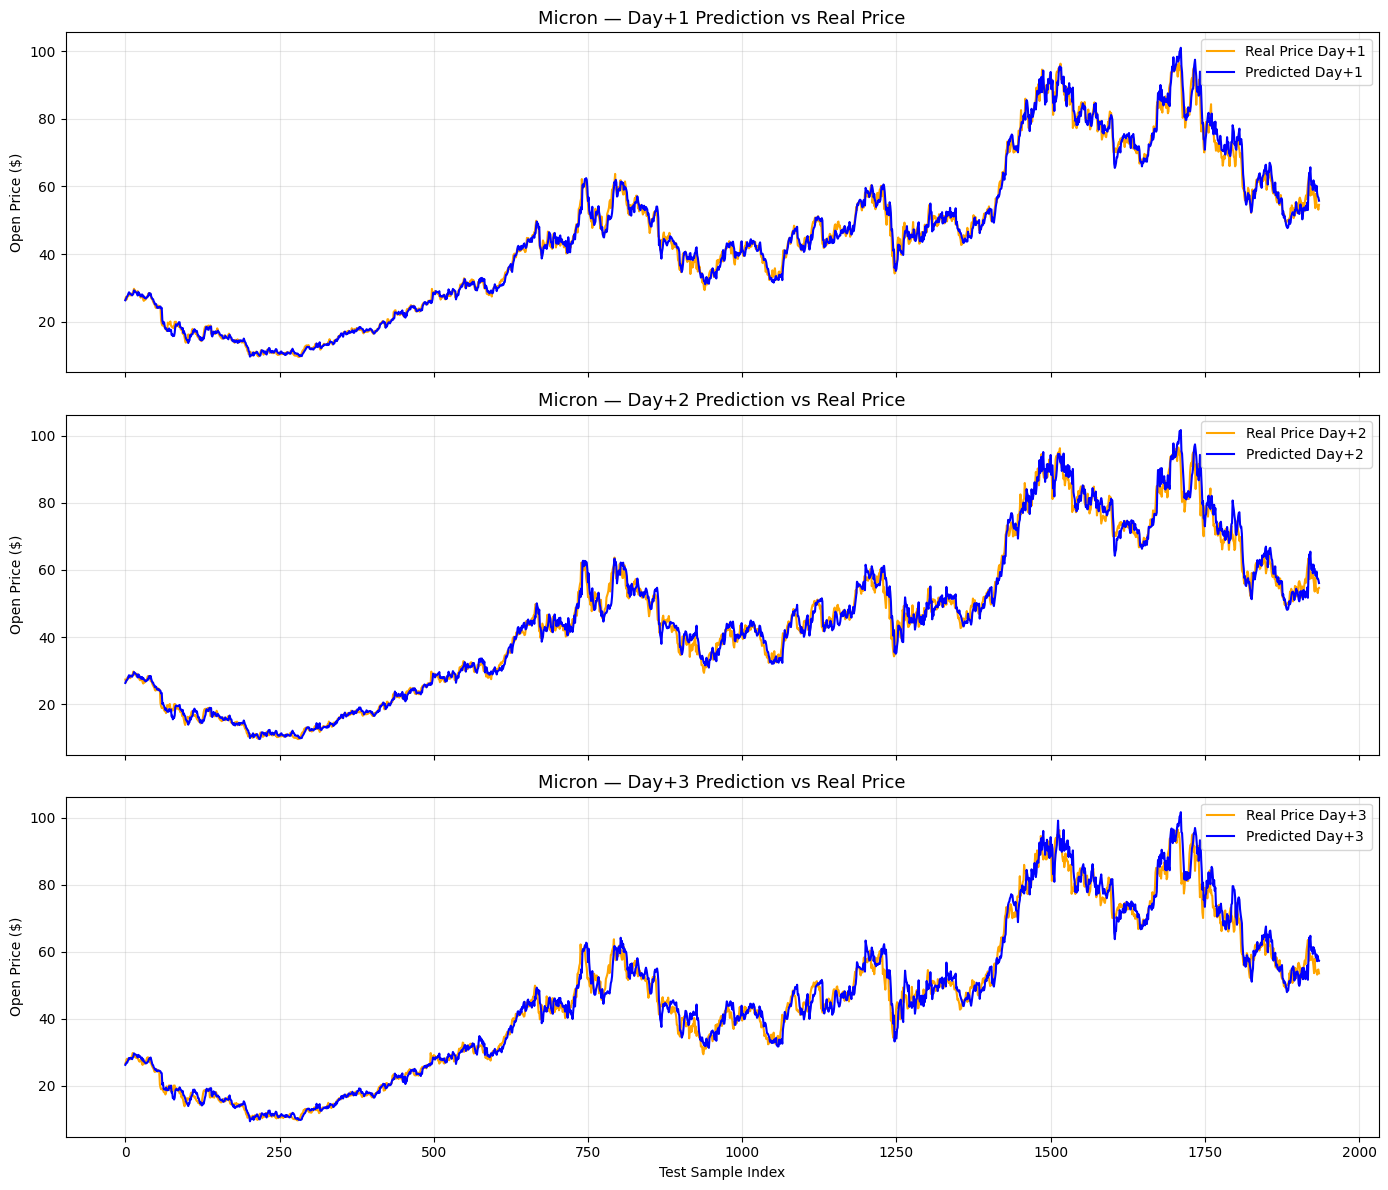

Prediction on Micron complete.


In [ ]:
# Plot
fig, axes = plt.subplots(n_ahead, 1, figsize=(14, 4 * n_ahead), sharex=True)

for day in range(n_ahead):
    axes[day].plot(y_new_te_raw[:, day],
                   label=f'Real Price Day+{day+1}',      color='orange')
    axes[day].plot(wf_new_raw[:, day],
                   label=f'Predicted Day+{day+1}',       color='blue')
    axes[day].set_title(f'{TICKER_LABEL} — Day+{day+1} Prediction vs Real Price', fontsize=13)
    axes[day].set_ylabel('Open Price ($)')
    axes[day].legend()
    axes[day].grid(alpha=0.3)

axes[-1].set_xlabel('Test Sample Index')
plt.tight_layout()
plt.show()

print(f'Prediction on {TICKER_LABEL} complete.')